# Lab Work 2

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from gensim.models import FastText
from gensim.models import KeyedVectors
import nltk
import nltk.corpus
import nltk.tokenize
from nltk.corpus import stopwords
from string import punctuation
import re
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, TensorDataset
from huggingface_hub import hf_hub_download
from collections import defaultdict
import datetime
import matplotlib.pyplot as plt
import seaborn as sns


/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

In [2]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /home/danya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/danya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
path_to_data = 'data/'
path_to_fasttext = 'fasttext/'
path_to_models = 'models/'
negative_file = path_to_data + 'negative.csv'
positive_file = path_to_data + 'positive.csv'
fasttext_model = path_to_fasttext + 'model.model'
fasttext_model = '/home/danya/develop/HomeWorks/NLP/fasttext/model.model'

In [4]:
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

In [5]:
negative_df = negative_df[:1000]
positive_df = positive_df[:1000]

In [6]:
sentiment = pd.concat([negative_df, positive_df])
sentiment=sentiment.loc[:,['ttext', 'ttype']]

In [7]:
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
995,@Denis_Shvedak Рискни) В рамку не эту тогда) И...,1
996,@Lei_Ri Спасибо) считаю найти свое место очень...,1
997,уаааа)))))) сейчас около меня прошел паренек с...,1
998,За монгол коментийн 2 оо vзэж жаахан хэрэгт ду...,1


## Preprocessing 

In [8]:
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [9]:
punctuations = list(punctuation)
punkt = ['``','...',"''",'«','»','…','”','”','“','-','–','..']
punctuations.extend(punkt)

stop_words = set(stopwords.words('russian'))
stop = []
for i in stop_words:
  if i not in ['нет','не','хорошо','иногда',
               'наконец','ни','никогда','ничего',
               'опять','разве','совсем','уже']:
      stop.append(i)

def tokenize(text):
    text = re.sub('[^ЙйёЁА-Яа-я0-9 ]', '', text)
    text = re.sub('\s+', ' ', text).strip()
    text_token = nltk.word_tokenize(text)
    text_word = [x.lower() for x in text_token if x not in punctuations]
    text_word = [i for i in text_word if i not in stop]
    return text_word


In [10]:
X_token = [tokenize(t) for t in X]

In [11]:
X_token[:10]

[['работе', 'полный', 'пиддес', 'каждое', 'закрытие', 'месяца', 'свихнусь'],
 ['коллеги', 'сидят', 'рубятся', 'изза', 'долбанной', 'винды', 'не', 'могу'],
 ['4', 'говорят', 'обещаного', 'года', 'ждут'],
 ['желаю',
  'хорошего',
  'полёта',
  'удачной',
  'посадкия',
  'буду',
  'очень',
  'сильно',
  'скучать',
  '3'],
 ['обновил', 'какимто', 'лешим', 'не', 'работает', 'простоплеер'],
 ['котёнка', 'вчера', 'носик', 'разбила', 'плакала', 'расстраивалась'],
 ['55',
  'зашли',
  'опять',
  'затихарился',
  'прямо',
  'физически',
  'страдаю',
  'долго',
  'молчит'],
 ['вообще', 'не', 'болею', 'не', 'выздоравливаю'],
 ['микрофраза', 'учимся', 'срать', 'кирпичами', 'режиме', 'нонстоп'],
 ['хочу', 'тобой', 'помириться', 'сука', 'гордая', 'никогда', 'не', 'сделаю']]

## Fasttext

### Создание слоёв автоматически

In [12]:
def create_model(input_dim, layers_config, output_dim):
    class DynamicFeedForwardNN(nn.Module):
        def __init__(self, input_dim, layers_config, output_dim):
            super(DynamicFeedForwardNN, self).__init__()
            
            if isinstance(layers_config, int):
                hidden_dims = [layers_config] * len(layers_config)
            elif isinstance(layers_config, (list, tuple)):
                hidden_dims = layers_config
            else:
                raise ValueError("layers_config должен быть int или list")
            
            layers = []
            prev_dim = input_dim
            
            for i, dim in enumerate(hidden_dims):
                layers.append(nn.Linear(prev_dim, dim))
                layers.append(nn.ReLU())
                prev_dim = dim
                
            layers.append(nn.Linear(prev_dim, output_dim))
            layers.append(nn.Softmax(dim=1))
            
            self.layers = nn.Sequential(*layers)
            self.num_layers = len(hidden_dims)
            
        def forward(self, x):
            return self.layers(x)
    
    return DynamicFeedForwardNN(input_dim, layers_config, output_dim)

### Извлечение признаков из FastText

In [13]:
def extract_features(tokens):
    model_path = hf_hub_download(repo_id="facebook/fasttext-ru-vectors", filename="model.bin")
    fasttext_model = fasttext.load_model(model_path)
    
    features = []
    for token_list in tokens:
        vectors = [fasttext_model.get_word_vector(token) for token in token_list]
        if len(vectors) > 0:
            avg_vector = np.mean(vectors, axis=0)
        else:
            avg_vector = np.zeros(fasttext_model.get_dimension())
        features.append(avg_vector)
    return np.array(features)

### Подготовка данных

In [14]:
def prepare_data(X_features, y, test_size=0.2, batch_size=32):
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=test_size, random_state=42
    )
    
    X_train_tensor = torch.FloatTensor(X_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_train_tensor = torch.LongTensor(y_train)
    y_test_tensor = torch.LongTensor(y_test)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    return train_loader, test_loader, len(X_train), len(X_test)

### Evaluation

In [15]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs.data, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return accuracy, f1, all_preds, all_labels

### Training

In [16]:
def train_model(model, train_loader, test_loader, num_epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    epoch_history = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward(retain_graph=True)
            optimizer.step()
            epoch_loss += loss.item()
        
        accuracy, f1, _, _ = evaluate_model(model, test_loader)
        epoch_loss /= len(train_loader)
        
        epoch_metrics = {
            'epoch': epoch+1,
            'train_loss': epoch_loss,
            'test_accuracy': accuracy,
            'test_f1_score': f1
        }
        epoch_history.append(epoch_metrics)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, '
              f'Test Accuracy: {accuracy:.2f}%, F1 Score: {f1:.4f}')
    
    return epoch_history

In [17]:
def run_experiment(results, X_token, y, model_name="model", 
                  layers_config=128, learning_rate=0.001, num_epochs=10):
    results[model_name] = {}
    
    X_features = extract_features(X_token)
    input_dim = X_features.shape[1]
    output_dim = len(np.unique(y))
    
    train_loader, test_loader, train_size, test_size = prepare_data(X_features, y)
    
    model = create_model(input_dim, layers_config, output_dim)
    
    results[model_name]['model_architecture'] = {
        'type': 'DynamicFeedForwardNN',
        'input_dim': input_dim,
        'layers_config': layers_config,
        'output_dim': output_dim,
        'num_layers': model.num_layers if hasattr(model, 'num_layers') else len(layers_config),
        'activation': 'ReLU',
        'output_activation': 'Softmax'
    }
    
    training_params = {
        'criterion': 'CrossEntropyLoss',
        'optimizer': 'Adam',
        'learning_rate': learning_rate,
        'batch_size': 32,
        'num_epochs': num_epochs
    }
    results[model_name]['training_params'] = training_params
    
    epoch_history = train_model(
        model, 
        train_loader, 
        test_loader, 
        num_epochs=num_epochs, 
        lr=learning_rate
    )
    
    results[model_name]['epoch_history'] = epoch_history
    
    best_epoch = max(epoch_history, key=lambda x: x['test_f1_score'])
    
    results[model_name]['final_metrics'] = {
        'best_epoch': best_epoch['epoch'],
        'best_accuracy': best_epoch['test_accuracy'],
        'best_f1_score': best_epoch['test_f1_score'],
        'final_loss': epoch_history[-1]['train_loss'],
        'training_time': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    
    model_save_path = path_to_models + f'{model_name}.pth'
    torch.save(model.state_dict(), model_save_path)
    results[model_name]['model_path'] = model_save_path
    
    print("\n=== Final Results ===")
    print(f"Model Name: {model_name}")
    print(f"Layers Config: {layers_config}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Best Accuracy: {results[model_name]['final_metrics']['best_accuracy']:.2f}%")
    print(f"Best F1 Score: {results[model_name]['final_metrics']['best_f1_score']:.4f}")
    print("=== Final Results ===\n")

In [18]:
def compare_models(results):
    metrics_df = visualize_results(results)

    print("=== Сравнение моделей ===")
    display(metrics_df.sort_values('Best F1 Score', ascending=False))
    
    best_model = metrics_df.loc[metrics_df['Best F1 Score'].idxmax()]
    print("\n=== Лучшая модель ===")
    print(f"Название: {best_model['Model']}")
    print(f"Конфигурация слоев: {best_model['Layers']}")
    print(f"Learning rate: {best_model['Learning Rate']}")
    print(f"Accuracy: {best_model['Best Accuracy']:.2f}%")
    print(f"F1 Score: {best_model['Best F1 Score']:.4f}")
    print(f"Final Loss: {best_model['Final Loss']:.4f}")
    
    return metrics_df

In [19]:
def run_and_compare_experiments(X_token, y, experiments_config):
    results = defaultdict(dict)
    
    for exp in experiments_config:
        run_experiment(
            results=results,
            X_token=X_token,
            y=y,
            model_name=exp['name'],
            layers_config=exp['layers'],
            learning_rate=exp['lr'],
            num_epochs=exp.get('epochs', 10)
        )
    
    metrics_df = compare_models(results)
    
    return results, metrics_df


In [20]:
def visualize_results(results):
    history_data = []
    metrics_data = []
    
    for model_name, model_data in results.items():
        for epoch in model_data['epoch_history']:
            history_data.append({
                'Model': model_name,
                'Epoch': epoch['epoch'],
                'Train Loss': epoch['train_loss'],
                'Test Accuracy': epoch['test_accuracy'],
                'Test F1': epoch['test_f1_score']
            })
        
        metrics_data.append({
            'Model': model_name,
            'Layers': str(model_data['model_architecture']['layers_config']),
            'Learning Rate': model_data['training_params']['learning_rate'],
            'Best Accuracy': model_data['final_metrics']['best_accuracy'],
            'Best F1 Score': model_data['final_metrics']['best_f1_score'],
            'Final Loss': model_data['final_metrics']['final_loss']
        })
    
    history_df = pd.DataFrame(history_data)
    metrics_df = pd.DataFrame(metrics_data)
    
    sns.set_style("whitegrid")
    palette = sns.color_palette("husl", len(results))
    
    plt.figure(figsize=(12, 18))
    
    plt.subplot(3, 1, 1)
    sns.lineplot(x='Epoch', y='Train Loss', hue='Model', 
                 data=history_df, palette=palette, linewidth=2.5)
    plt.title('Динамика функции потерь (Loss)', fontsize=14)
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Эпоха', fontsize=12)
    plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.subplot(3, 1, 2)
    sns.lineplot(x='Epoch', y='Test Accuracy', hue='Model', 
                 data=history_df, palette=palette, linewidth=2.5)
    plt.title('Динамика точности (Accuracy)', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('Эпоха', fontsize=12)
    plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.subplot(3, 1, 3)
    sns.lineplot(x='Epoch', y='Test F1', hue='Model', 
                 data=history_df, palette=palette, linewidth=2.5)
    plt.title('Динамика F1 Score', fontsize=14)
    plt.ylabel('F1 Score', fontsize=12)
    plt.xlabel('Эпоха', fontsize=12)
    plt.legend(title='Модель', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 1, 1)
    ax = sns.barplot(x='Model', y='Best Accuracy', hue='Model', 
                    data=metrics_df, palette='Blues_d', dodge=False, legend=False)
    plt.title('Сравнение Accuracy моделей', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('')
    plt.xticks(rotation=45)
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 10), 
                   textcoords='offset points')
    
    plt.subplot(2, 1, 2)
    ax = sns.barplot(x='Model', y='Best F1 Score', hue='Model', 
                    data=metrics_df, palette='Greens_d', dodge=False, legend=False)
    plt.title('Сравнение F1 Score моделей', fontsize=14)
    plt.ylabel('F1 Score', fontsize=12)
    plt.xlabel('')
    plt.xticks(rotation=45)
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 10), 
                   textcoords='offset points')
    
    plt.tight_layout()
    plt.show()
    
    return metrics_df

Epoch [1/10], Loss: 0.6657, Test Accuracy: 65.75%, F1 Score: 0.6572
Epoch [2/10], Loss: 0.6106, Test Accuracy: 69.00%, F1 Score: 0.6900
Epoch [3/10], Loss: 0.5897, Test Accuracy: 69.00%, F1 Score: 0.6900
Epoch [4/10], Loss: 0.5768, Test Accuracy: 64.75%, F1 Score: 0.6388
Epoch [5/10], Loss: 0.5676, Test Accuracy: 69.50%, F1 Score: 0.6946
Epoch [6/10], Loss: 0.5544, Test Accuracy: 68.25%, F1 Score: 0.6823
Epoch [7/10], Loss: 0.5490, Test Accuracy: 68.25%, F1 Score: 0.6793
Epoch [8/10], Loss: 0.5416, Test Accuracy: 67.75%, F1 Score: 0.6775
Epoch [9/10], Loss: 0.5349, Test Accuracy: 66.75%, F1 Score: 0.6675
Epoch [10/10], Loss: 0.5353, Test Accuracy: 68.25%, F1 Score: 0.6824

=== Final Results ===
Model Name: 32-32_lr0.01
Layers Config: [32, 32]
Learning Rate: 0.01
Best Accuracy: 69.50%
Best F1 Score: 0.6946
=== Final Results ===

Epoch [1/10], Loss: 0.6683, Test Accuracy: 66.75%, F1 Score: 0.6665
Epoch [2/10], Loss: 0.6132, Test Accuracy: 69.25%, F1 Score: 0.6903
Epoch [3/10], Loss: 0.58

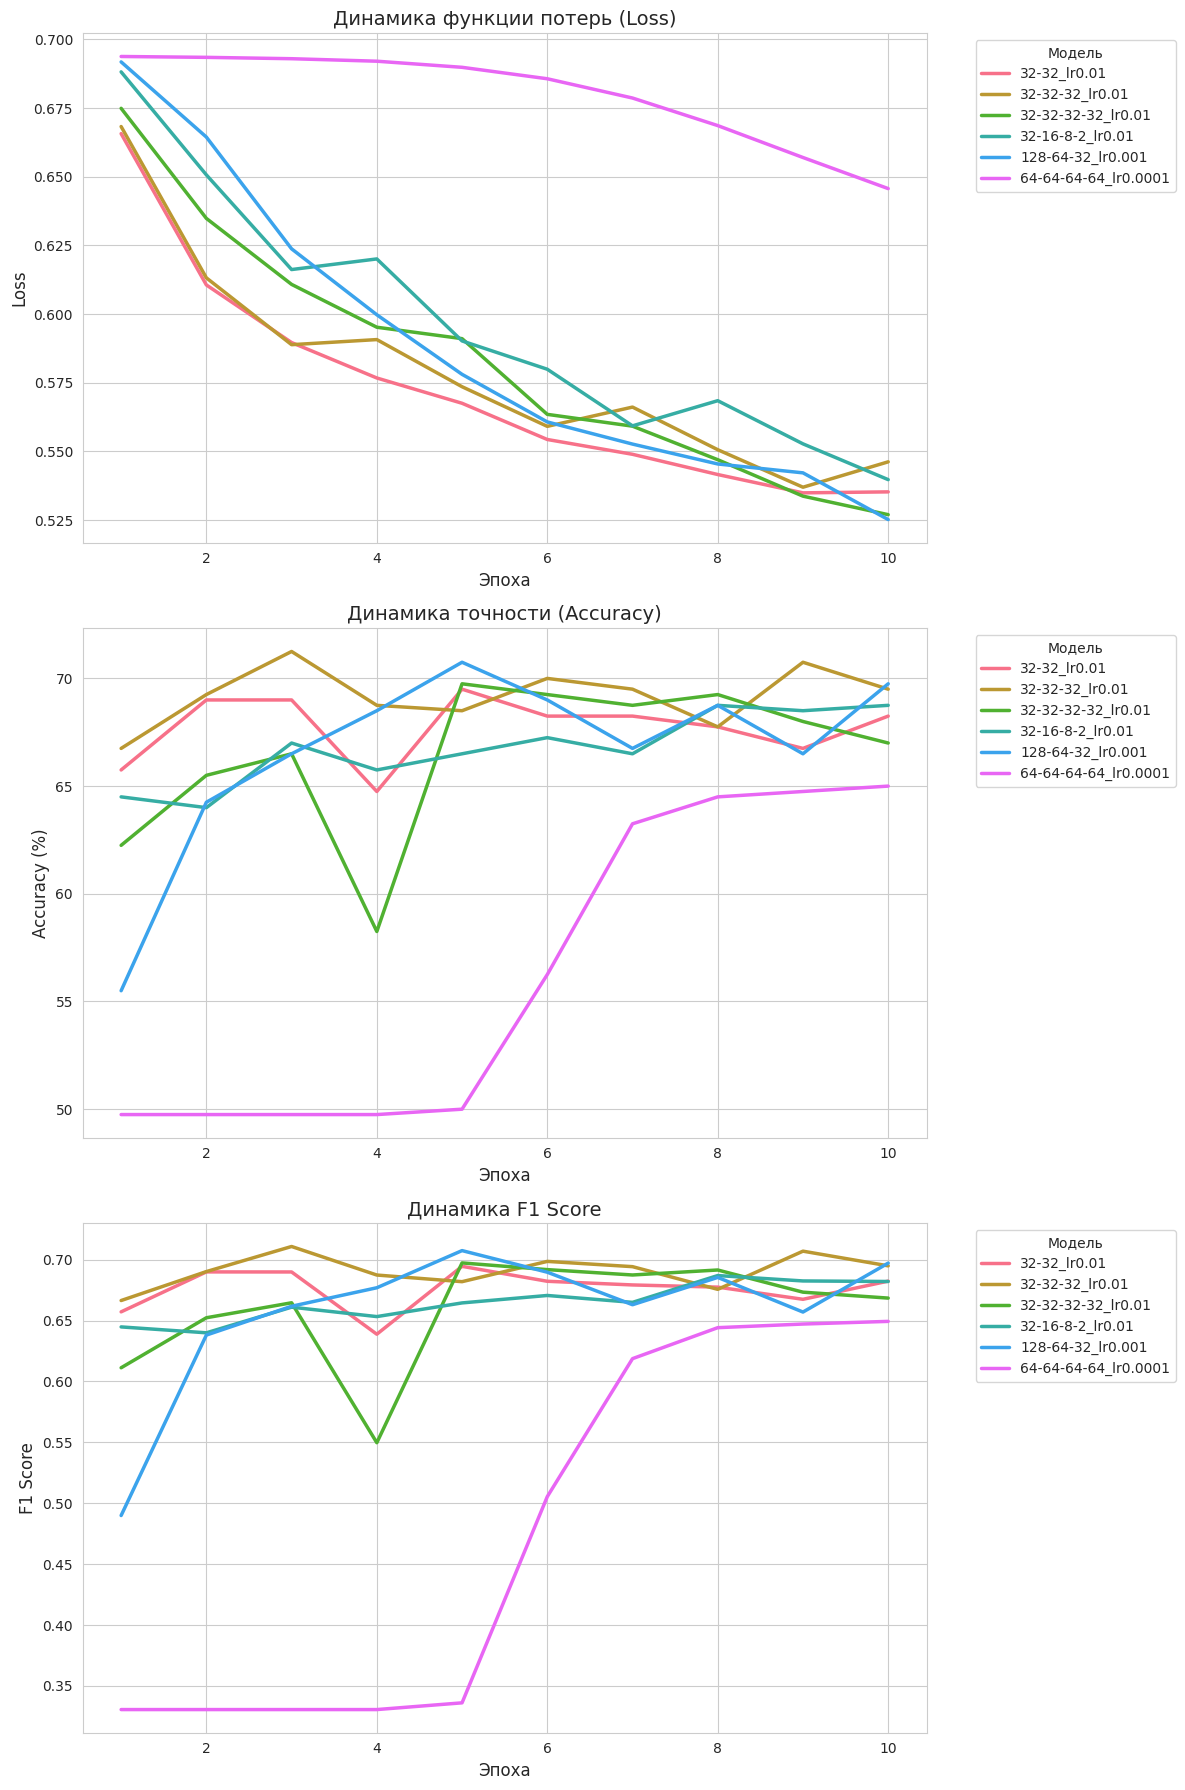

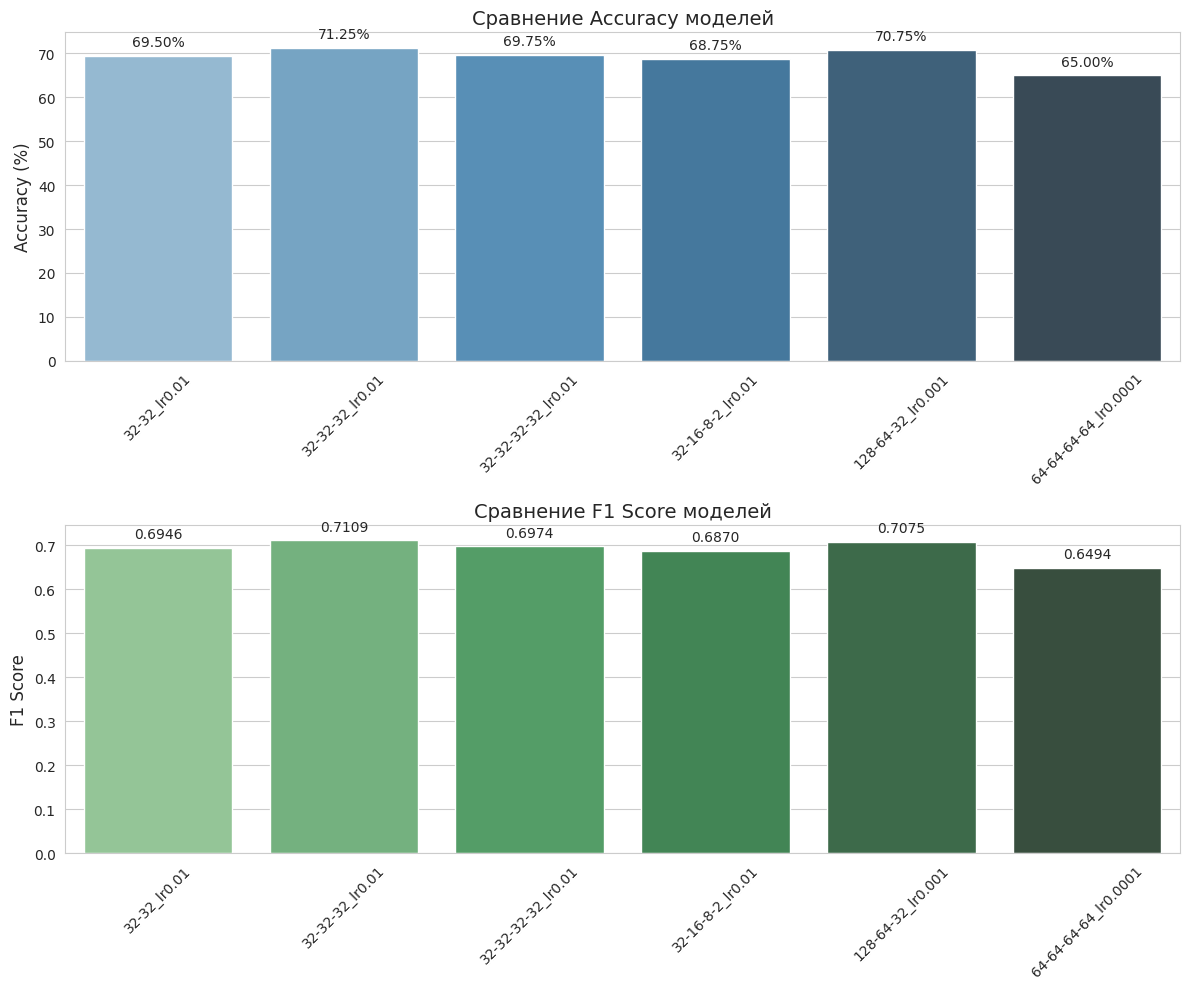

=== Сравнение моделей ===


,Model,Layers,Learning Rate,Best Accuracy,Best F1 Score,Final Loss
1,32-32-32_lr0.01,"[32, 32, 32]",0.0100,71.25,0.710875,0.546233
4,128-64-32_lr0.001,"[128, 64, 32]",0.0010,70.75,0.707495,0.525210
2,32-32-32-32_lr0.01,"[32, 32, 32, 32]",0.0100,69.75,0.697381,0.526994
0,32-32_lr0.01,"[32, 32]",0.0100,69.50,0.694572,0.535294
3,32-16-8-2_lr0.01,"[32, 16, 8, 2]",0.0100,68.75,0.687001,0.539749
5,64-64-64-64_lr0.0001,"[64, 64, 64, 64]",0.0001,65.00,0.649369,0.645704



=== Лучшая модель ===
Название: 32-32-32_lr0.01
Конфигурация слоев: [32, 32, 32]
Learning rate: 0.01
Accuracy: 71.25%
F1 Score: 0.7109
Final Loss: 0.5462


In [21]:
if __name__ == "__main__":
    experiments = [
        {'name': '32-32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32-32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
        {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
        {'name': '64-64-64-64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10}
    ]
    # experiments = [
    #     # 2 слоя (одинаковые нейроны)
    #     {'name': '32x32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32_lr0.001', 'layers': [32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32_lr0.0001', 'layers': [32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64_lr0.01', 'layers': [64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64_lr0.001', 'layers': [64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64_lr0.0001', 'layers': [64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128_lr0.01', 'layers': [128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128_lr0.001', 'layers': [128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128_lr0.0001', 'layers': [128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 2 слоя (разные нейроны)
    #     {'name': '32-16_lr0.01', 'layers': [32, 16], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16_lr0.001', 'layers': [32, 16], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16_lr0.0001', 'layers': [32, 16], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64-32_lr0.01', 'layers': [64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32_lr0.001', 'layers': [64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32_lr0.0001', 'layers': [64, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     # 3 слоя (одинаковые нейроны)
    #     {'name': '32x32x32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32_lr0.001', 'layers': [32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32_lr0.0001', 'layers': [32, 32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64x64_lr0.01', 'layers': [64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64_lr0.001', 'layers': [64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64_lr0.0001', 'layers': [64, 64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128x128_lr0.01', 'layers': [128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128_lr0.001', 'layers': [128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128_lr0.0001', 'layers': [128, 128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 3 слоя (разные нейроны)
    #     {'name': '32-16-8_lr0.01', 'layers': [32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8_lr0.001', 'layers': [32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8_lr0.0001', 'layers': [32, 16, 8], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128-64-32_lr0.01', 'layers': [128, 64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128-64-32_lr0.0001', 'layers': [128, 64, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     # 4 слоя (одинаковые нейроны)
    #     {'name': '32x32x32x32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.001', 'layers': [32, 32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.0001', 'layers': [32, 32, 32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64x64x64_lr0.01', 'layers': [64, 64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.001', 'layers': [64, 64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128x128x128_lr0.01', 'layers': [128, 128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.001', 'layers': [128, 128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.0001', 'layers': [128, 128, 128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 4 слоя (разные нейроны)
    #     {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.001', 'layers': [32, 16, 8, 2], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.0001', 'layers': [32, 16, 8, 2], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64-32-16-8_lr0.01', 'layers': [64, 32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.001', 'layers': [64, 32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.0001', 'layers': [64, 32, 16, 8], 'lr': 0.0001, 'epochs': 10}
    # ]
    
    results_fasttext, metrics_df_fasttext = run_and_compare_experiments(X_token, y, experiments)

## Word to Vectores

In [22]:
import sys
import requests
from pymystem3 import Mystem

"""
Этот скрипт принимает на вход необработанный русский текст 
(одно предложение на строку или один абзац на строку).
Он токенизируется, лемматизируется и размечается по частям речи с использованием Mystem.
На выход подаётся последовательность разделенных пробелами лемм с частями речи 
("зеленый_NOUN трамвай_NOUN").
Их можно непосредственно использовать в моделях с RusVectōrēs (https://rusvectores.org).

Примеры запуска:
echo 'Мама мыла раму.' | python3 rus_preprocessing_mystem.py
zcat large_corpus.txt.gz | python3 rus_preprocessing_mystem.py | gzip > processed_corpus.txt.gz
"""


def tag_mystem(
    text="Текст нужно передать функции в виде строки!", mapping=None, postags=True
):
    # если частеречные тэги не нужны (например, их нет в модели), выставьте postags=False
    # в этом случае на выход будут поданы только леммы

    processed = m.analyze(text)
    tagged = []
    for w in processed:
        try:
            lemma = w["analysis"][0]["lex"].lower().strip()
            pos = w["analysis"][0]["gr"].split(",")[0]
            pos = pos.split("=")[0].strip()
            if mapping:
                if pos in mapping:
                    pos = mapping[pos]  # здесь мы конвертируем тэги
                else:
                    pos = "X"  # на случай, если попадется тэг, которого нет в маппинге
            tagged.append(lemma.lower() + "_" + pos)
        except KeyError:
            continue  # я здесь пропускаю знаки препинания, но вы можете поступить по-другому
    if not postags:
        tagged = [t.split("_")[0] for t in tagged]
    return tagged


# Таблица преобразования частеречных тэгов Mystem в тэги UPoS:
mapping_url = "https://raw.githubusercontent.com/akutuzov/universal-pos-tags/4653e8a9154e93fe2f417c7fdb7a357b7d6ce333/ru-rnc.map"

mystem2upos = {}
r = requests.get(mapping_url, stream=True)
for pair in r.text.split("\n"):
    pair = pair.split()
    if len(pair) > 1:
        mystem2upos[pair[0]] = pair[1]

print("Loading the model...", file=sys.stderr)
m = Mystem()

print("Processing input...", file=sys.stderr)
for line in sys.stdin:
    res = line.strip()
    output = tag_mystem(text=res, mapping=mystem2upos)
    print(" ".join(output))

Loading the model...
Processing input...


In [23]:
def extract_features(tokens):
    word2vec_model = KeyedVectors.load_word2vec_format("word2vec/model.bin", binary=True)
    
    if not hasattr(extract_features, 'mystem_initialized'):
        mapping_url = "https://raw.githubusercontent.com/akutuzov/universal-pos-tags/4653e8a9154e93fe2f417c7fdb7a357b7d6ce333/ru-rnc.map"
        mystem2upos = {}
        r = requests.get(mapping_url)
        for pair in r.text.split("\n"):
            pair = pair.split()
            if len(pair) > 1:
                mystem2upos[pair[0]] = pair[1]
        
        extract_features.m = Mystem()
        extract_features.mystem2upos = mystem2upos
        extract_features.mystem_initialized = True
    
    features = []
    for token_list in tokens:
        text = ' '.join(token_list)
        processed_tokens = []
        for w in extract_features.m.analyze(text):
            # Skip tokens without analysis
            if not w.get("analysis"):
                continue
                
            try:
                lemma = w["analysis"][0]["lex"].lower().strip()
                pos = w["analysis"][0]["gr"].split(",")[0].split("=")[0].strip()
                pos = extract_features.mystem2upos.get(pos, "X")
                processed_tokens.append(f"{lemma}_{pos}")
            except (KeyError, IndexError):
                continue
        
        vectors = []
        for token in processed_tokens:
            try:
                vectors.append(word2vec_model[token])
            except KeyError:
                # Skip words not in vocabulary
                continue
        
        if vectors:
            avg_vector = np.mean(vectors, axis=0)
        else:
            avg_vector = np.zeros(word2vec_model.vector_size)
        
        features.append(avg_vector)
    
    return np.array(features)

Epoch [1/10], Loss: 0.6823, Test Accuracy: 61.50%, F1 Score: 0.6149
Epoch [2/10], Loss: 0.6302, Test Accuracy: 62.25%, F1 Score: 0.6216
Epoch [3/10], Loss: 0.5876, Test Accuracy: 62.25%, F1 Score: 0.6179
Epoch [4/10], Loss: 0.5642, Test Accuracy: 61.00%, F1 Score: 0.6097
Epoch [5/10], Loss: 0.5844, Test Accuracy: 61.50%, F1 Score: 0.6150
Epoch [6/10], Loss: 0.5488, Test Accuracy: 60.50%, F1 Score: 0.6043
Epoch [7/10], Loss: 0.5247, Test Accuracy: 59.50%, F1 Score: 0.5943
Epoch [8/10], Loss: 0.5059, Test Accuracy: 58.25%, F1 Score: 0.5820
Epoch [9/10], Loss: 0.5088, Test Accuracy: 62.25%, F1 Score: 0.6223
Epoch [10/10], Loss: 0.4883, Test Accuracy: 58.75%, F1 Score: 0.5860

=== Final Results ===
Model Name: 32-32_lr0.01
Layers Config: [32, 32]
Learning Rate: 0.01
Best Accuracy: 62.25%
Best F1 Score: 0.6223
=== Final Results ===

Epoch [1/10], Loss: 0.6884, Test Accuracy: 60.75%, F1 Score: 0.6063
Epoch [2/10], Loss: 0.6380, Test Accuracy: 61.25%, F1 Score: 0.6109
Epoch [3/10], Loss: 0.60

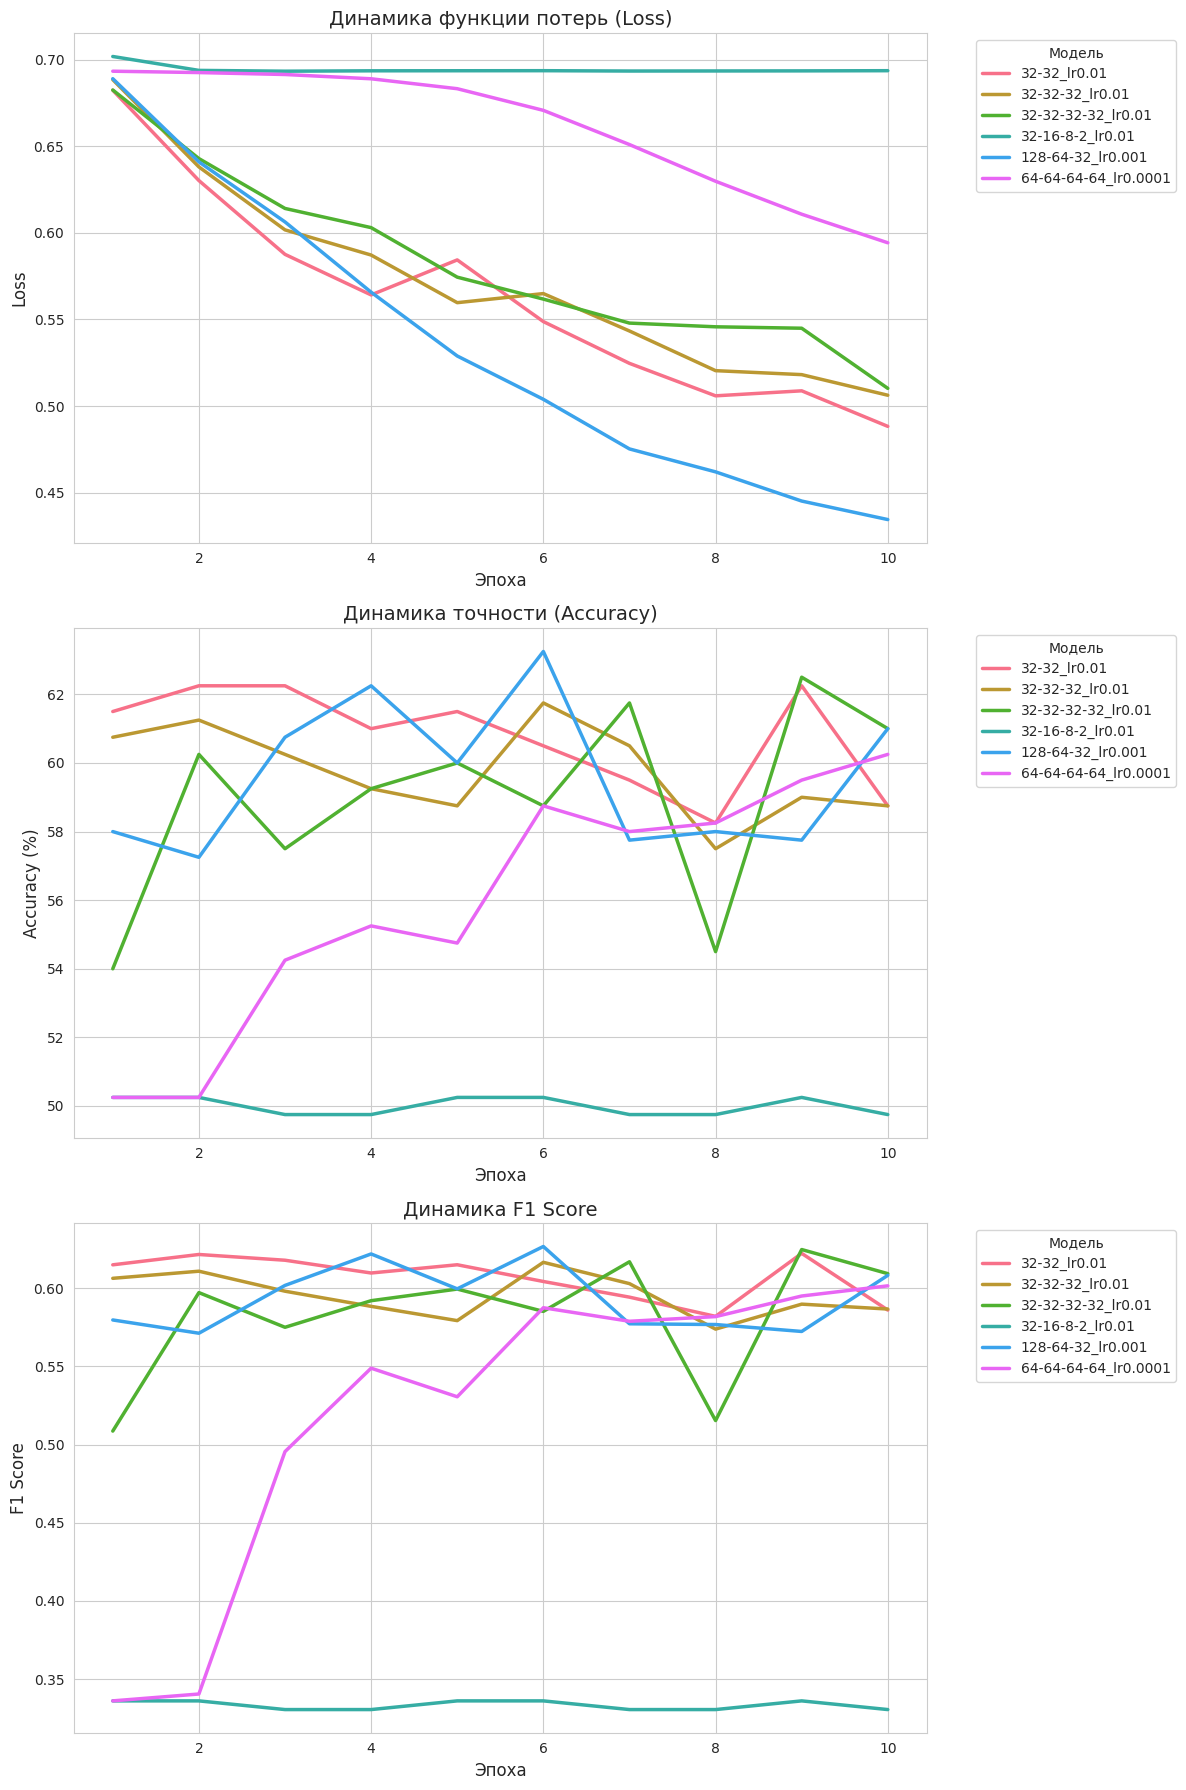

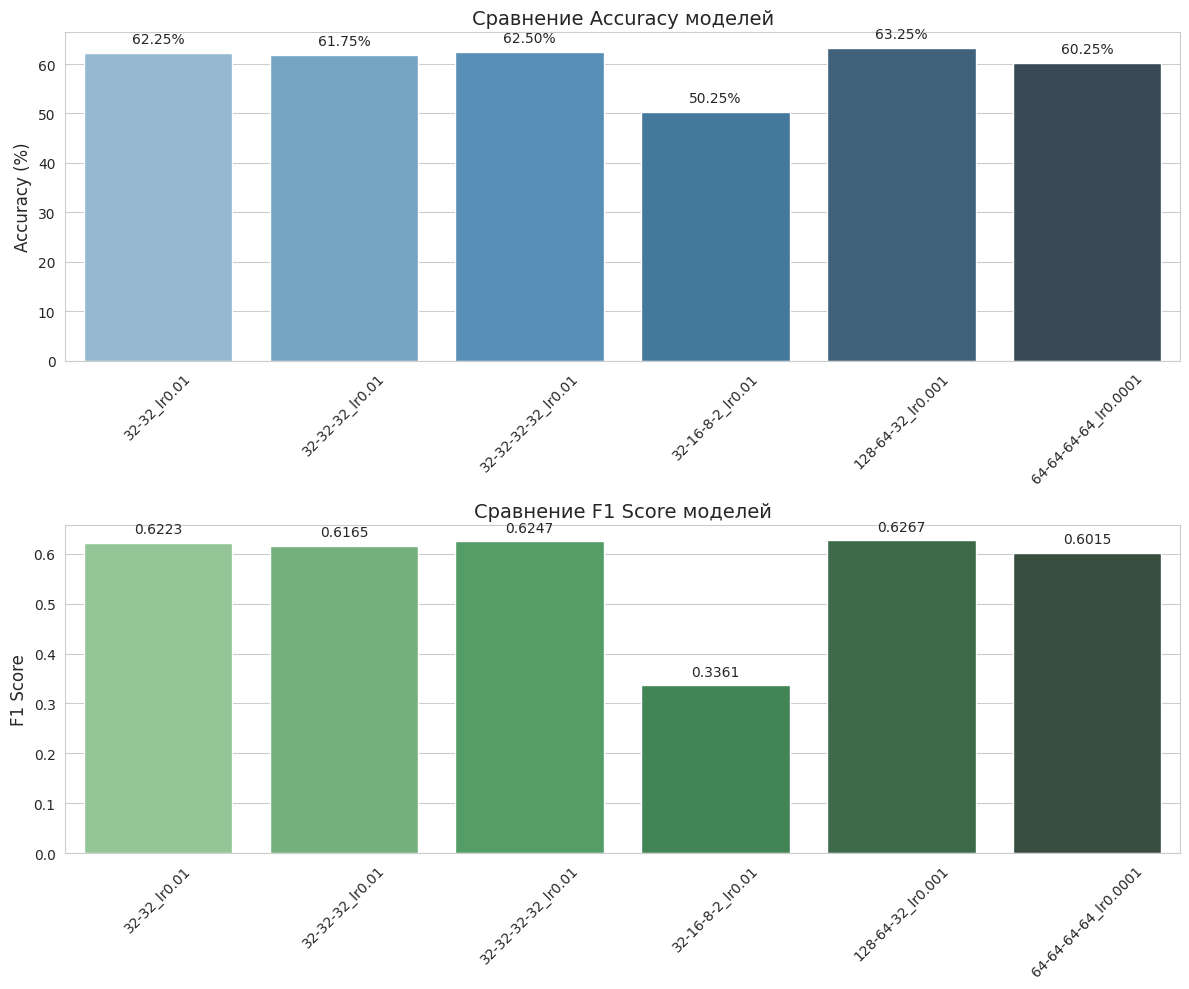

=== Сравнение моделей ===


,Model,Layers,Learning Rate,Best Accuracy,Best F1 Score,Final Loss
4,128-64-32_lr0.001,"[128, 64, 32]",0.0010,63.25,0.626665,0.434526
2,32-32-32-32_lr0.01,"[32, 32, 32, 32]",0.0100,62.50,0.624718,0.510237
0,32-32_lr0.01,"[32, 32]",0.0100,62.25,0.622266,0.488305
1,32-32-32_lr0.01,"[32, 32, 32]",0.0100,61.75,0.616544,0.506271
5,64-64-64-64_lr0.0001,"[64, 64, 64, 64]",0.0001,60.25,0.601506,0.594249
3,32-16-8-2_lr0.01,"[32, 16, 8, 2]",0.0100,50.25,0.336115,0.693554



=== Лучшая модель ===
Название: 128-64-32_lr0.001
Конфигурация слоев: [128, 64, 32]
Learning rate: 0.001
Accuracy: 63.25%
F1 Score: 0.6267
Final Loss: 0.4345


In [24]:
if __name__ == "__main__":
    experiments = [
        {'name': '32-32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32-32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
        {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
        {'name': '64-64-64-64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10}
    ]
    # experiments = [
    #     # 2 слоя (одинаковые нейроны)
    #     {'name': '32x32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32_lr0.001', 'layers': [32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32_lr0.0001', 'layers': [32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64_lr0.01', 'layers': [64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64_lr0.001', 'layers': [64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64_lr0.0001', 'layers': [64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128_lr0.01', 'layers': [128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128_lr0.001', 'layers': [128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128_lr0.0001', 'layers': [128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 2 слоя (разные нейроны)
    #     {'name': '32-16_lr0.01', 'layers': [32, 16], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16_lr0.001', 'layers': [32, 16], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16_lr0.0001', 'layers': [32, 16], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64-32_lr0.01', 'layers': [64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32_lr0.001', 'layers': [64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32_lr0.0001', 'layers': [64, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     # 3 слоя (одинаковые нейроны)
    #     {'name': '32x32x32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32_lr0.001', 'layers': [32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32_lr0.0001', 'layers': [32, 32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64x64_lr0.01', 'layers': [64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64_lr0.001', 'layers': [64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64_lr0.0001', 'layers': [64, 64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128x128_lr0.01', 'layers': [128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128_lr0.001', 'layers': [128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128_lr0.0001', 'layers': [128, 128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 3 слоя (разные нейроны)
    #     {'name': '32-16-8_lr0.01', 'layers': [32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8_lr0.001', 'layers': [32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8_lr0.0001', 'layers': [32, 16, 8], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128-64-32_lr0.01', 'layers': [128, 64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128-64-32_lr0.0001', 'layers': [128, 64, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     # 4 слоя (одинаковые нейроны)
    #     {'name': '32x32x32x32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.001', 'layers': [32, 32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.0001', 'layers': [32, 32, 32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64x64x64_lr0.01', 'layers': [64, 64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.001', 'layers': [64, 64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128x128x128_lr0.01', 'layers': [128, 128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.001', 'layers': [128, 128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.0001', 'layers': [128, 128, 128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 4 слоя (разные нейроны)
    #     {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.001', 'layers': [32, 16, 8, 2], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.0001', 'layers': [32, 16, 8, 2], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64-32-16-8_lr0.01', 'layers': [64, 32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.001', 'layers': [64, 32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.0001', 'layers': [64, 32, 16, 8], 'lr': 0.0001, 'epochs': 10}
    # ]
    
    results_word2vec, metrics_df_word2vec = run_and_compare_experiments(X_token, y, experiments)

## Embedding

In [30]:
def build_vocab(tokenized_texts):
    vocab = defaultdict(int)
    for text in tokenized_texts:
        for token in text:
            vocab[token] += 1
    vocab = {word: i+2 for i, word in enumerate(vocab)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

vocab = build_vocab(X_token)
vocab_size = len(vocab)
embedding_dim = 1000

def text_to_sequence(tokens, vocab, max_len=100):
    seq = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    if len(seq) < max_len:
        seq += [vocab['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

X_seq = [text_to_sequence(tokens, vocab) for tokens in X_token]

In [31]:
def create_model(input_dim, layers_config, output_dim):
    class DynamicFeedForwardNN(nn.Module):
        def __init__(self, input_dim, layers_config, output_dim):
            super(DynamicFeedForwardNN, self).__init__()
            
            if isinstance(layers_config, int):
                hidden_dims = [layers_config] * len(layers_config)
            elif isinstance(layers_config, (list, tuple)):
                hidden_dims = layers_config
            else:
                raise ValueError("layers_config должен быть int или list")
            
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            prev_dim = embedding_dim
            
            layers = []
            for i, dim in enumerate(hidden_dims):
                layers.append(nn.Linear(prev_dim, dim))
                layers.append(nn.ReLU())
                prev_dim = dim
                
            layers.append(nn.Linear(prev_dim, output_dim))
            layers.append(nn.Softmax(dim=1))
            
            self.layers = nn.Sequential(*layers)
            self.num_layers = len(hidden_dims)
            
        def forward(self, x):
            x = self.embedding(x.long())
            x = torch.mean(x, dim=1)
            return self.layers(x)
    
    return DynamicFeedForwardNN(input_dim, layers_config, output_dim)

def extract_features(tokens):
    return np.array([text_to_sequence(t, vocab) for t in tokens])

def prepare_data(X_features, y, test_size=0.2, batch_size=32):
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=test_size, random_state=42
    )
    
    X_train_tensor = torch.LongTensor(X_train)
    X_test_tensor = torch.LongTensor(X_test)
    y_train_tensor = torch.LongTensor(y_train)
    y_test_tensor = torch.LongTensor(y_test)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    return train_loader, test_loader, len(X_train), len(X_test)

def run_experiment(results, X_token, y, model_name="model", 
                  layers_config=128, learning_rate=0.001, num_epochs=10):
    results[model_name] = {}
    
    X_features = extract_features(X_token)
    input_dim = embedding_dim
    output_dim = len(np.unique(y))
    
    train_loader, test_loader, train_size, test_size = prepare_data(
        X_features, y
    )
    
    model = create_model(input_dim, layers_config, output_dim)
    
    results[model_name]['model_architecture'] = {
        'type': 'DynamicFeedForwardNN',
        'input_dim': input_dim,
        'layers_config': layers_config,
        'output_dim': output_dim,
        'num_layers': model.num_layers if hasattr(model, 'num_layers') else len(layers_config),
        'activation': 'ReLU',
        'output_activation': 'Softmax'
    }
    
    training_params = {
        'criterion': 'CrossEntropyLoss',
        'optimizer': 'Adam',
        'learning_rate': learning_rate,
        'batch_size': 32,
        'num_epochs': num_epochs
    }
    results[model_name]['training_params'] = training_params
    
    epoch_history = train_model(
        model, 
        train_loader, 
        test_loader, 
        num_epochs=num_epochs, 
        lr=learning_rate
    )
    
    results[model_name]['epoch_history'] = epoch_history
    
    best_epoch = max(epoch_history, key=lambda x: x['test_f1_score'])
    
    results[model_name]['final_metrics'] = {
        'best_epoch': best_epoch['epoch'],
        'best_accuracy': best_epoch['test_accuracy'],
        'best_f1_score': best_epoch['test_f1_score'],
        'final_loss': epoch_history[-1]['train_loss'],
        'training_time': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    
    model_save_path = path_to_models + f'{model_name}.pth'
    torch.save(model.state_dict(), model_save_path)
    results[model_name]['model_path'] = model_save_path
    
    print("\n=== Final Results ===")
    print(f"Model Name: {model_name}")
    print(f"Layers Config: {layers_config}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Best Accuracy: {results[model_name]['final_metrics']['best_accuracy']:.2f}%")
    print(f"Best F1 Score: {results[model_name]['final_metrics']['best_f1_score']:.4f}")
    print("=== Final Results ===\n")

Epoch [1/10], Loss: 0.7001, Test Accuracy: 50.25%, F1 Score: 0.3361
Epoch [2/10], Loss: 0.6951, Test Accuracy: 48.25%, F1 Score: 0.3470
Epoch [3/10], Loss: 0.6942, Test Accuracy: 49.75%, F1 Score: 0.3306
Epoch [4/10], Loss: 0.6936, Test Accuracy: 50.25%, F1 Score: 0.3361
Epoch [5/10], Loss: 0.6933, Test Accuracy: 50.25%, F1 Score: 0.3361
Epoch [6/10], Loss: 0.6934, Test Accuracy: 49.75%, F1 Score: 0.3306
Epoch [7/10], Loss: 0.6934, Test Accuracy: 49.75%, F1 Score: 0.3306
Epoch [8/10], Loss: 0.6936, Test Accuracy: 50.25%, F1 Score: 0.3361
Epoch [9/10], Loss: 0.6933, Test Accuracy: 49.75%, F1 Score: 0.3306
Epoch [10/10], Loss: 0.6936, Test Accuracy: 49.75%, F1 Score: 0.3306

=== Final Results ===
Model Name: 32-32_lr0.01
Layers Config: [32, 32]
Learning Rate: 0.01
Best Accuracy: 48.25%
Best F1 Score: 0.3470
=== Final Results ===

Epoch [1/10], Loss: 0.7005, Test Accuracy: 49.75%, F1 Score: 0.3306
Epoch [2/10], Loss: 0.6936, Test Accuracy: 49.75%, F1 Score: 0.3306
Epoch [3/10], Loss: 0.69

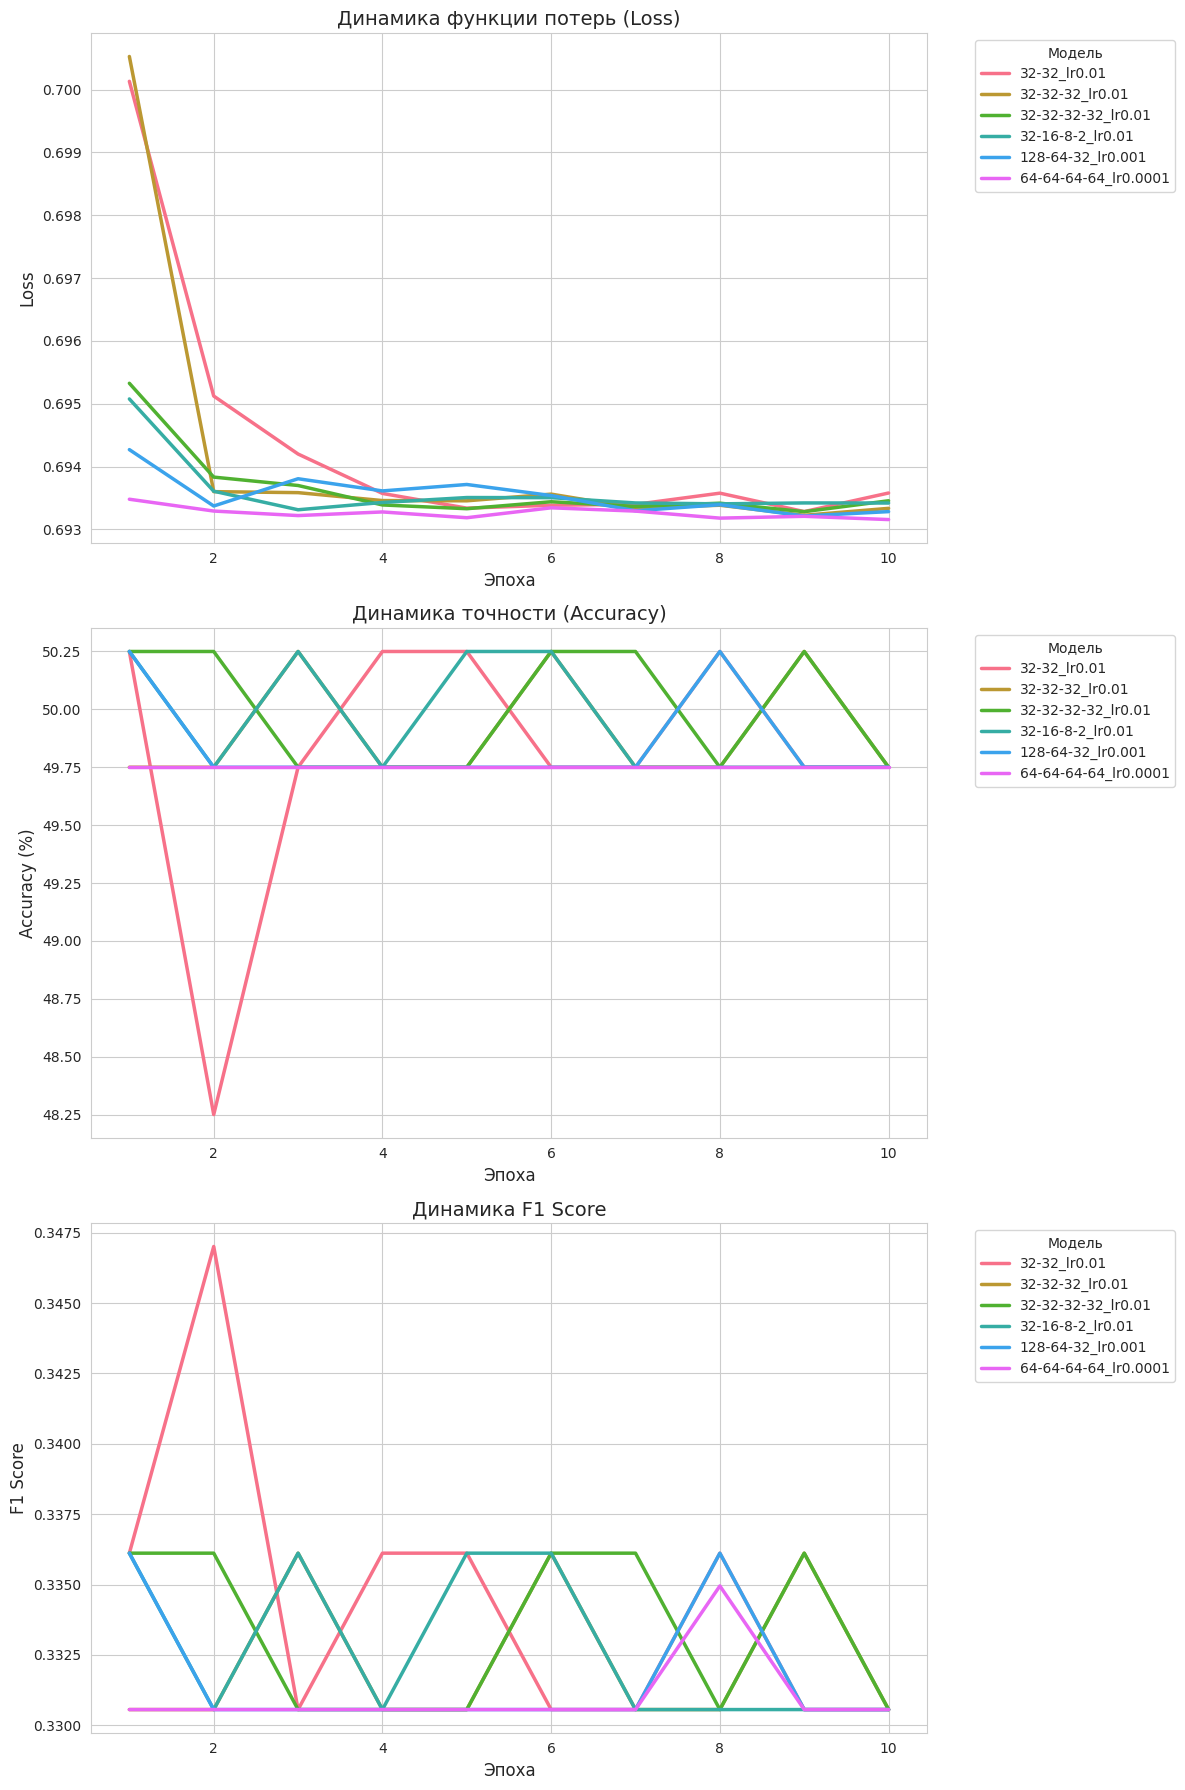

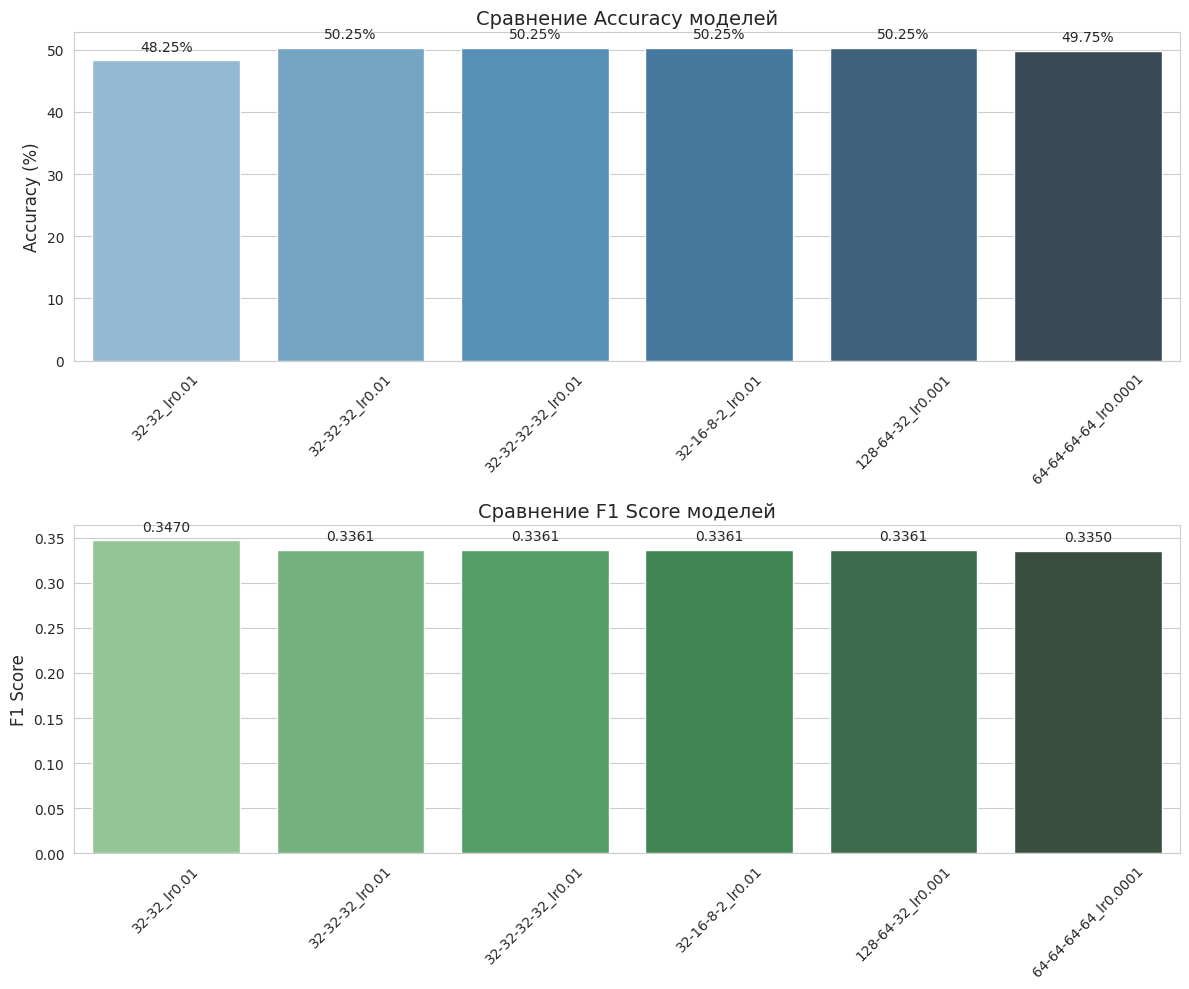

=== Сравнение моделей ===


,Model,Layers,Learning Rate,Best Accuracy,Best F1 Score,Final Loss
0,32-32_lr0.01,"[32, 32]",0.0100,48.25,0.347009,0.693580
1,32-32-32_lr0.01,"[32, 32, 32]",0.0100,50.25,0.336115,0.693336
2,32-32-32-32_lr0.01,"[32, 32, 32, 32]",0.0100,50.25,0.336115,0.693456
3,32-16-8-2_lr0.01,"[32, 16, 8, 2]",0.0100,50.25,0.336115,0.693420
4,128-64-32_lr0.001,"[128, 64, 32]",0.0010,50.25,0.336115,0.693284
5,64-64-64-64_lr0.0001,"[64, 64, 64, 64]",0.0001,49.75,0.334951,0.693157



=== Лучшая модель ===
Название: 32-32_lr0.01
Конфигурация слоев: [32, 32]
Learning rate: 0.01
Accuracy: 48.25%
F1 Score: 0.3470
Final Loss: 0.6936


In [32]:
if __name__ == "__main__":
    experiments = [
        {'name': '32-32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-32-32-32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
        {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
        {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
        {'name': '64-64-64-64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10}
    ]
    # experiments = [
    #     # 2 слоя (одинаковые нейроны)
    #     {'name': '32x32_lr0.01', 'layers': [32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32_lr0.001', 'layers': [32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32_lr0.0001', 'layers': [32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64_lr0.01', 'layers': [64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64_lr0.001', 'layers': [64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64_lr0.0001', 'layers': [64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128_lr0.01', 'layers': [128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128_lr0.001', 'layers': [128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128_lr0.0001', 'layers': [128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 2 слоя (разные нейроны)
    #     {'name': '32-16_lr0.01', 'layers': [32, 16], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16_lr0.001', 'layers': [32, 16], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16_lr0.0001', 'layers': [32, 16], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64-32_lr0.01', 'layers': [64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32_lr0.001', 'layers': [64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32_lr0.0001', 'layers': [64, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     # 3 слоя (одинаковые нейроны)
    #     {'name': '32x32x32_lr0.01', 'layers': [32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32_lr0.001', 'layers': [32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32_lr0.0001', 'layers': [32, 32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64x64_lr0.01', 'layers': [64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64_lr0.001', 'layers': [64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64_lr0.0001', 'layers': [64, 64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128x128_lr0.01', 'layers': [128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128_lr0.001', 'layers': [128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128_lr0.0001', 'layers': [128, 128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 3 слоя (разные нейроны)
    #     {'name': '32-16-8_lr0.01', 'layers': [32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8_lr0.001', 'layers': [32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8_lr0.0001', 'layers': [32, 16, 8], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128-64-32_lr0.01', 'layers': [128, 64, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128-64-32_lr0.001', 'layers': [128, 64, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128-64-32_lr0.0001', 'layers': [128, 64, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     # 4 слоя (одинаковые нейроны)
    #     {'name': '32x32x32x32_lr0.01', 'layers': [32, 32, 32, 32], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.001', 'layers': [32, 32, 32, 32], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32x32x32x32_lr0.0001', 'layers': [32, 32, 32, 32], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64x64x64x64_lr0.01', 'layers': [64, 64, 64, 64], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.001', 'layers': [64, 64, 64, 64], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64x64x64x64_lr0.0001', 'layers': [64, 64, 64, 64], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '128x128x128x128_lr0.01', 'layers': [128, 128, 128, 128], 'lr': 0.01, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.001', 'layers': [128, 128, 128, 128], 'lr': 0.001, 'epochs': 10},
    #     {'name': '128x128x128x128_lr0.0001', 'layers': [128, 128, 128, 128], 'lr': 0.0001, 'epochs': 10},
        
    #     # 4 слоя (разные нейроны)
    #     {'name': '32-16-8-2_lr0.01', 'layers': [32, 16, 8, 2], 'lr': 0.01, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.001', 'layers': [32, 16, 8, 2], 'lr': 0.001, 'epochs': 10},
    #     {'name': '32-16-8-2_lr0.0001', 'layers': [32, 16, 8, 2], 'lr': 0.0001, 'epochs': 10},
        
    #     {'name': '64-32-16-8_lr0.01', 'layers': [64, 32, 16, 8], 'lr': 0.01, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.001', 'layers': [64, 32, 16, 8], 'lr': 0.001, 'epochs': 10},
    #     {'name': '64-32-16-8_lr0.0001', 'layers': [64, 32, 16, 8], 'lr': 0.0001, 'epochs': 10}
    # ]
    
    results_embedding, metrics_df_embedding = run_and_compare_experiments(X_token, y, experiments)

In [33]:
results = defaultdict(dict)
results['word2vec'] = results_word2vec
results['embedding'] = results_embedding
results['fasttext'] = results_fasttext

metrics = defaultdict(dict)
metrics['embedding'] = metrics_df_embedding
metrics['word2vec'] = metrics_df_word2vec
metrics['fasttext'] = metrics_df_fasttext

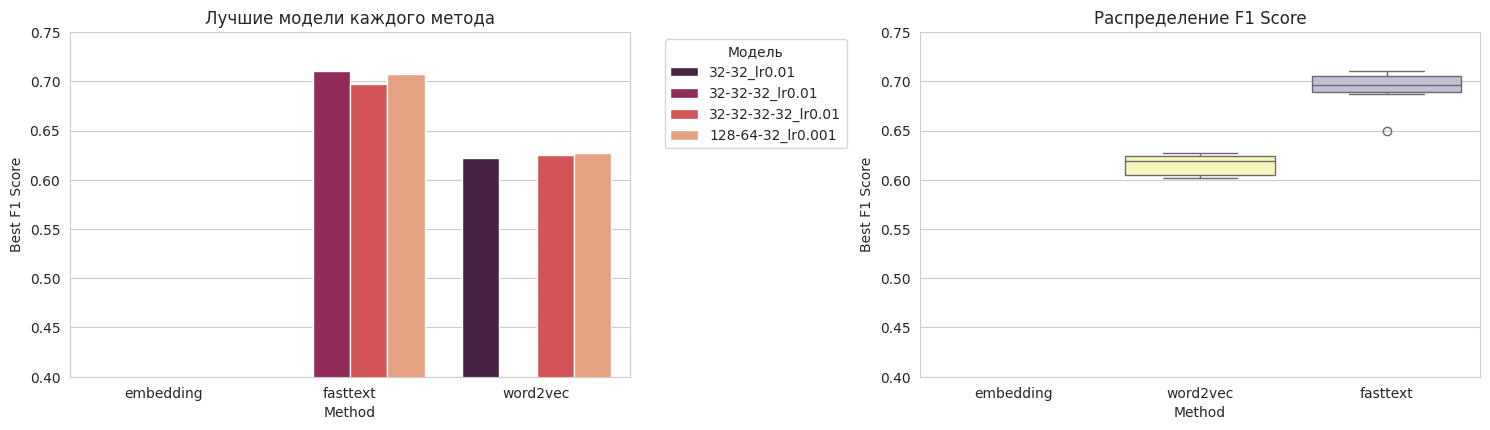

Топ-5 моделей по F1 Score:


,Rank,Method,Model,Best F1 Score,Best Accuracy,Final Loss
13,1,fasttext,32-32-32_lr0.01,0.710875,71.25,0.546233
16,2,fasttext,128-64-32_lr0.001,0.707495,70.75,0.525210
14,3,fasttext,32-32-32-32_lr0.01,0.697381,69.75,0.526994
12,4,fasttext,32-32_lr0.01,0.694572,69.50,0.535294
15,5,fasttext,32-16-8-2_lr0.01,0.687001,68.75,0.539749



Топ-3 модели каждого метода:


,Method,Model,Best F1 Score,Best Accuracy,Final Loss
0,embedding,32-32_lr0.01,0.347009,48.25,0.693580
1,embedding,32-32-32_lr0.01,0.336115,50.25,0.693336
2,embedding,32-32-32-32_lr0.01,0.336115,50.25,0.693456
13,fasttext,32-32-32_lr0.01,0.710875,71.25,0.546233
16,fasttext,128-64-32_lr0.001,0.707495,70.75,0.525210
14,fasttext,32-32-32-32_lr0.01,0.697381,69.75,0.526994
10,word2vec,128-64-32_lr0.001,0.626665,63.25,0.434526
8,word2vec,32-32-32-32_lr0.01,0.624718,62.50,0.510237
6,word2vec,32-32_lr0.01,0.622266,62.25,0.488305


In [34]:
full_df = pd.concat([
    metrics['embedding'].assign(Method='embedding'),
    metrics['word2vec'].assign(Method='word2vec'),
    metrics['fasttext'].assign(Method='fasttext')
]).reset_index(drop=True)

top_f1_global = full_df.nlargest(5, 'Best F1 Score').assign(Rank=range(1, 6))
top_f1_by_method = (full_df.sort_values(['Method', 'Best F1 Score'], ascending=[True, False])
                   .groupby('Method').head(3))

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
sns.barplot(data=top_f1_by_method, x='Method', y='Best F1 Score', 
           hue='Model', palette='rocket', dodge=True)
plt.title('Лучшие модели каждого метода')
plt.ylim(0.4, 0.75)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Модель')

plt.subplot(2, 2, 2)
sns.boxplot(data=full_df, x='Method', y='Best F1 Score', 
           hue='Method', palette='Set3', legend=False)
plt.title('Распределение F1 Score')
plt.ylim(0.4, 0.75)


plt.tight_layout()
plt.show()

print("Топ-5 моделей по F1 Score:")
display(top_f1_global[['Rank', 'Method', 'Model', 'Best F1 Score', 'Best Accuracy', 'Final Loss']]
       .sort_values('Rank'))

print("\nТоп-3 модели каждого метода:")
display(top_f1_by_method[['Method', 'Model', 'Best F1 Score', 'Best Accuracy', 'Final Loss']]
       .sort_values(['Method', 'Best F1 Score'], ascending=[True, False]))